In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Chargement des données
df = pd.read_parquet("../data/staged/vgsales_enriched.parquet")

print(f"✅ Dataset chargé : {len(df):,} jeux")
print(f"📋 Colonnes : {list(df.columns)}")

✅ Dataset chargé : 64,016 jeux
📋 Colonnes : ['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update', 'rawg_id', 'rawg_released', 'rawg_metacritic', 'rawg_developers', 'data_source']


In [2]:
# ── Statistiques générales ──────────────────────────────────
print("=" * 50)
print("  RÉSUMÉ DU DATASET")
print("=" * 50)
print(f"  Jeux uniques          : {df['title'].nunique():>10,}")
print(f"  Plateformes           : {df['console'].nunique():>10,}")
print(f"  Genres                : {df['genre'].nunique():>10,}")
print(f"  Éditeurs              : {df['publisher'].nunique():>10,}")

# Taux d'enrichissement RAWG
total = len(df)
enriched = df['rawg_id'].notna().sum()
print(f"\n  Enrichissement RAWG   : {enriched:,}/{total:,} ({enriched/total:.1%})")

# Nulls par colonne de ventes
print(f"\n  Ventes nulles :")
for col in ['na_sales', 'pal_sales', 'jp_sales', 'other_sales']:
    nulls = df[col].isna().sum()
    print(f"    {col:<15} : {nulls:,} nulls ({nulls/total:.1%})")
print("=" * 50)

  RÉSUMÉ DU DATASET
  Jeux uniques          :     39,798
  Plateformes           :         81
  Genres                :         20
  Éditeurs              :      3,383

  Enrichissement RAWG   : 3,304/64,016 (5.2%)

  Ventes nulles :
    na_sales        : 51,379 nulls (80.3%)
    pal_sales       : 51,192 nulls (80.0%)
    jp_sales        : 57,290 nulls (89.5%)
    other_sales     : 48,888 nulls (76.4%)


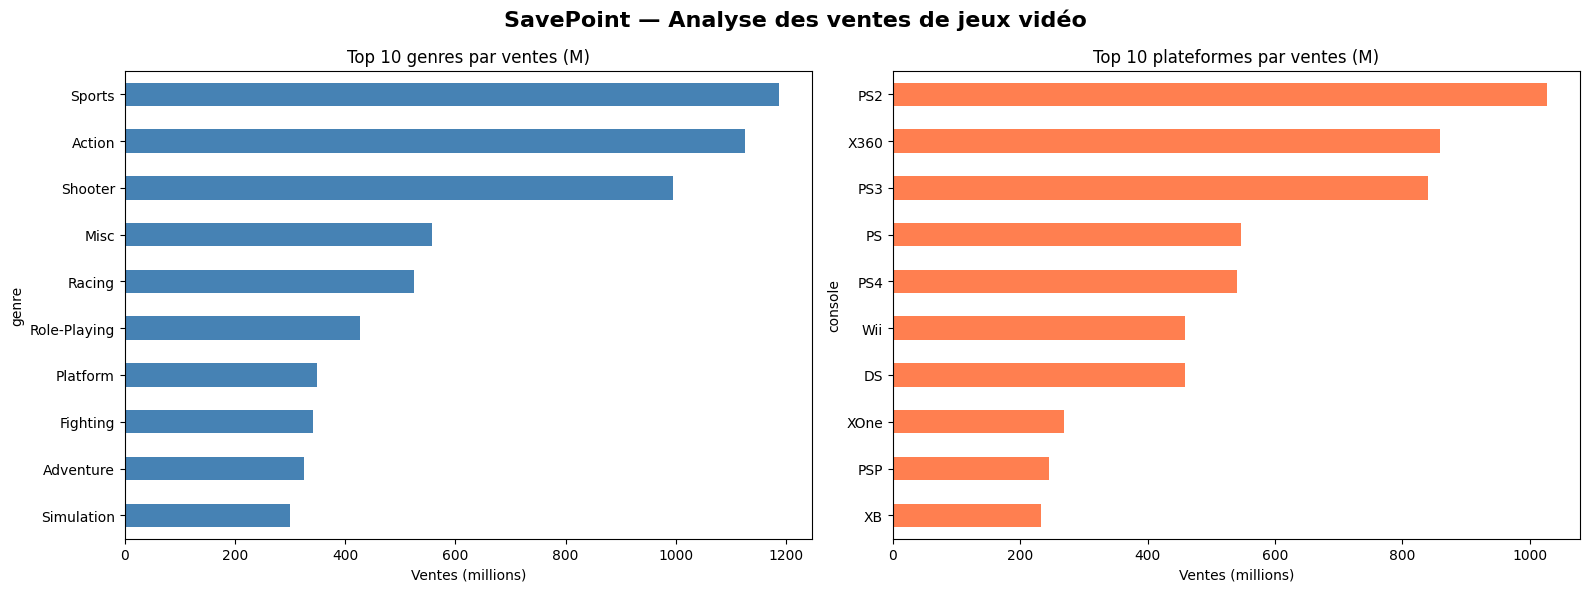

In [3]:
# ── Graphique 1 : Top 10 genres par ventes ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("SavePoint — Analyse des ventes de jeux vidéo", 
             fontsize=16, fontweight='bold')

# Top genres
genre_sales = df.groupby("genre")["total_sales"].sum().dropna().sort_values(ascending=True).tail(10)
genre_sales.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Top 10 genres par ventes (M)")
axes[0].set_xlabel("Ventes (millions)")

# Top plateformes
plat_sales = df.groupby("console")["total_sales"].sum().dropna().sort_values(ascending=True).tail(10)
plat_sales.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title("Top 10 plateformes par ventes (M)")
axes[1].set_xlabel("Ventes (millions)")

plt.tight_layout()
plt.show()

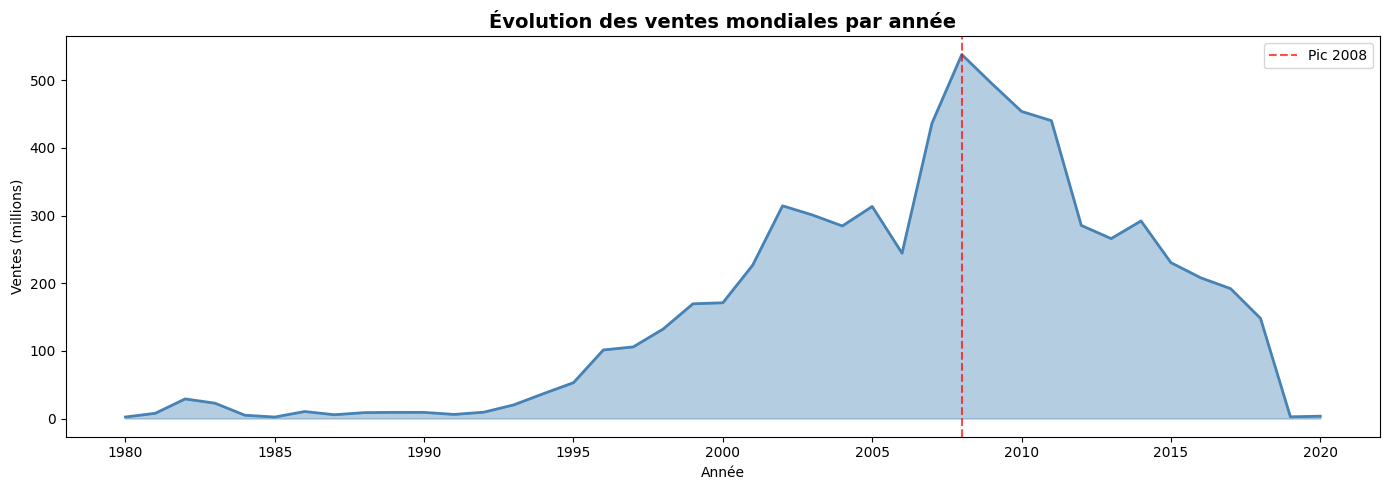

In [4]:
# ── Graphique 2 : Évolution des ventes par année ────────────
df["release_year"] = pd.to_datetime(df["release_date"], errors="coerce").dt.year

yearly = df.groupby("release_year")["total_sales"].sum().dropna()
yearly = yearly[(yearly.index >= 1980) & (yearly.index <= 2020)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(yearly.index, yearly.values, alpha=0.4, color='steelblue')
ax.plot(yearly.index, yearly.values, color='steelblue', linewidth=2)
ax.set_title("Évolution des ventes mondiales par année", fontsize=14, fontweight='bold')
ax.set_xlabel("Année")
ax.set_ylabel("Ventes (millions)")
ax.axvline(x=2008, color='red', linestyle='--', alpha=0.7, label='Pic 2008')
ax.legend()
plt.tight_layout()
plt.show()

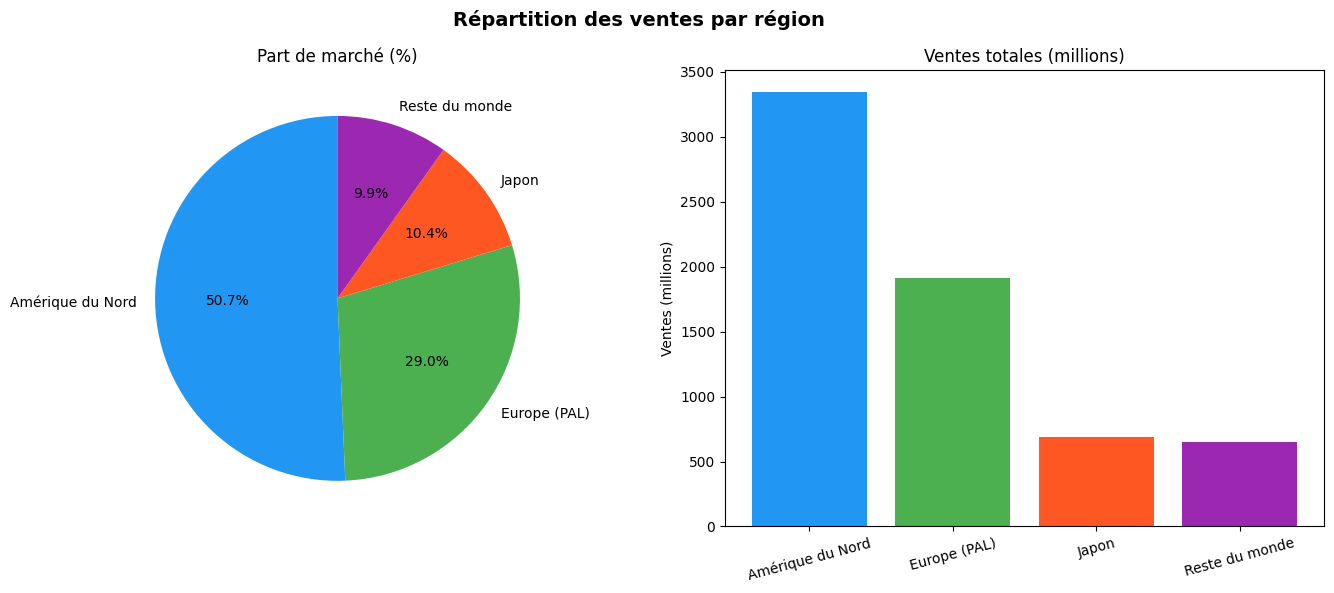

In [5]:
# ── Graphique 3 : Ventes par région ─────────────────────────
regions = {
    "Amérique du Nord": df["na_sales"].sum(),
    "Europe (PAL)":     df["pal_sales"].sum(),
    "Japon":            df["jp_sales"].sum(),
    "Reste du monde":   df["other_sales"].sum(),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Répartition des ventes par région", fontsize=14, fontweight='bold')

colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

# Camembert
ax1.pie(regions.values(), labels=regions.keys(), autopct='%1.1f%%',
        colors=colors, startangle=90)
ax1.set_title("Part de marché (%)")

# Barres
ax2.bar(regions.keys(), regions.values(), color=colors)
ax2.set_title("Ventes totales (millions)")
ax2.set_ylabel("Ventes (millions)")
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

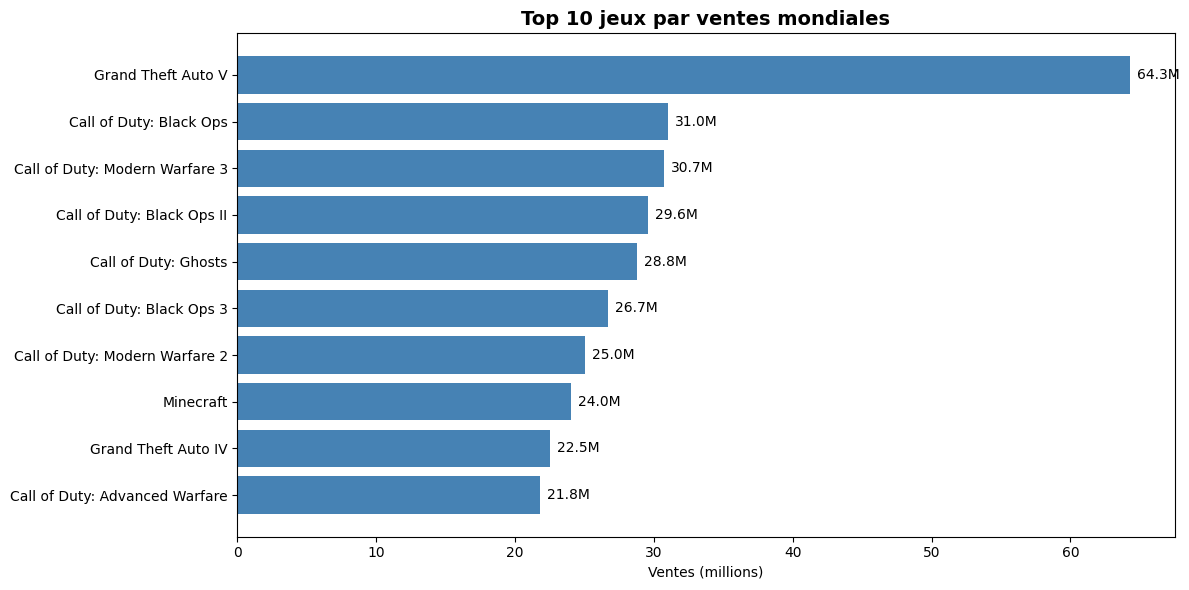

In [6]:
# ── Graphique 4 : Top 10 jeux par ventes mondiales ──────────
top_games = (
    df.groupby("title")["total_sales"]
    .sum()
    .dropna()
    .sort_values(ascending=True)
    .tail(10)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_games.index, top_games.values, color='steelblue')

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, top_games.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}M', va='center', fontsize=10)

ax.set_title("Top 10 jeux par ventes mondiales", fontsize=14, fontweight='bold')
ax.set_xlabel("Ventes (millions)")
plt.tight_layout()
plt.show()